<a href="https://colab.research.google.com/github/sakshi645/Music-Playlist---SQL-project/blob/main/movie_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load datasets
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')


In [ ]:
#merge datasets
data = pd.merge(ratings, movies, on= 'movieId')

In [ ]:
data.head(5)

,userId,movieId,rating,timestamp,title,genres
0,1,17.0,4.0,1999-12-03 19:24:37,Sense and Sensibility (1995),Drama|Romance
1,1,25.0,1.0,1999-12-03 19:43:48,Leaving Las Vegas (1995),Drama|Romance
2,1,29.0,2.0,1999-11-22 00:36:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
3,1,30.0,5.0,1999-12-03 19:24:37,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1,32.0,5.0,1999-11-22 00:00:58,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller


In [ ]:
#Clean datasets
data['timestamp'] = pd.to_datetime(data['timestamp'], unit = 's')

In [ ]:
#Top-Rated movies
top_rated = data.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)

In [ ]:
top_rated.head(5)

,rating
title,
United (2011),5.0
A Charlie Brown Thanksgiving (1973),5.0
The Electrical Life of Louis Wain (2021),5.0
A Creepshow Animated Special (2020),5.0
"Merry Widow, The (1925)",5.0


In [ ]:
#Average rating by genre
data['genres'] = data['genres'].fillna('').str.split('|')
data_exploded = data.explode('genres')

avg_rating_genre = data_exploded.groupby('genres')['rating'].mean().sort_values(ascending = False)


In [ ]:
print(avg_rating_genre)

genres
    3.568034
Name: rating, dtype: float64


In [ ]:
# ratings trends over time
data['year'] = data['timestamp'].dt.year
ratings_trends = data.groupby('year')['rating'].mean()

In [ ]:
print(ratings_trends)

year
1996.0    3.576388
1997.0    3.562721
1998.0    3.429348
1999.0    3.649462
2000.0    3.630162
2001.0    3.573354
2002.0    3.456025
2003.0    3.546419
2004.0    3.525952
2005.0    3.383062
2006.0    3.463069
2007.0    3.610972
2008.0    3.546158
2009.0    3.528310
2010.0    3.580334
2011.0    3.594616
2012.0    3.778194
2013.0    3.775078
2014.0    3.723894
2015.0    3.612944
2016.0    3.420635
2017.0    3.592392
2018.0    3.650635
2019.0    3.546393
2020.0    3.672638
2021.0    3.549546
2022.0    3.641139
2023.0    3.550916
Name: rating, dtype: float64


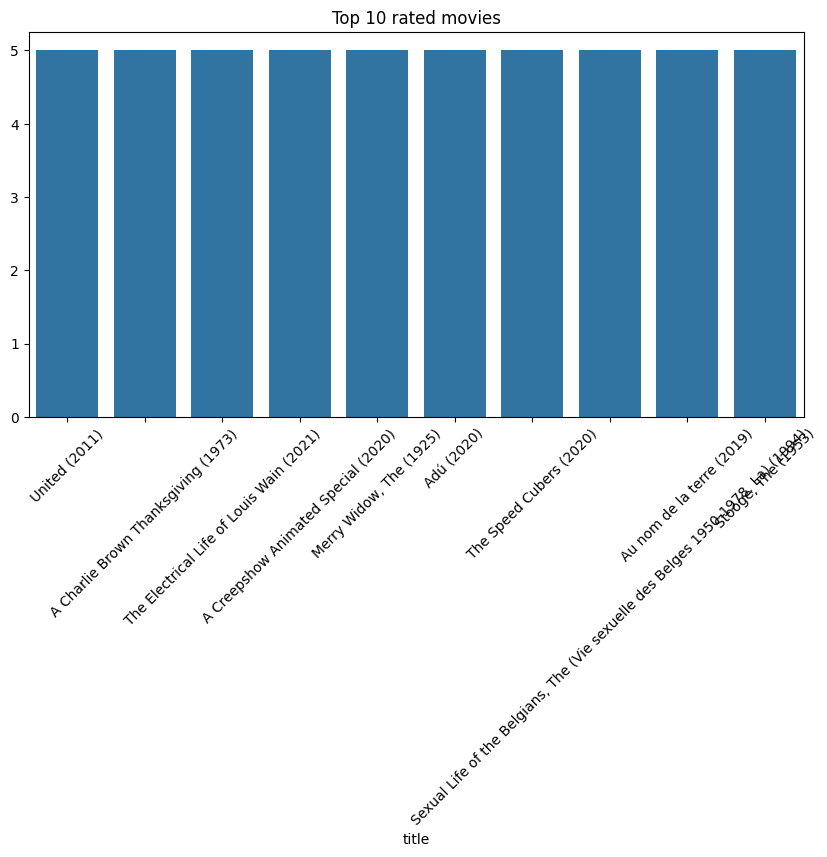

In [ ]:
# visualization
plt.figure(figsize = (10,5))
sns.barplot(x=top_rated.index, y=top_rated.values)
plt.title('Top 10 rated movies')
plt.xticks(rotation = 45)
plt.show()

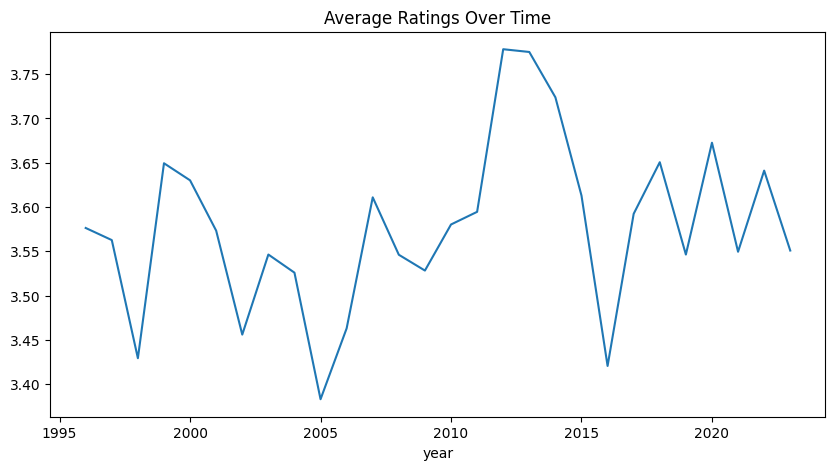

In [ ]:
plt.figure(figsize = (10,5))
sns.lineplot(x=ratings_trends.index, y=ratings_trends.values)
plt.title('Average Ratings Over Time')
plt.show()
